In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

In [ ]:
# Uncomment if using Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Uncomment if uploading directly in Colab
# from google.colab import files
# uploaded = files.upload()
DATA_PATH = '/content/creditcard.csv'  # <-- update this path

df = pd.read_csv(DATA_PATH)
df.shape

(1986, 31)

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1986 entries, 0 to 1985
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1986 non-null   int64  
 1   V1      1986 non-null   float64
 2   V2      1986 non-null   float64
 3   V3      1986 non-null   float64
 4   V4      1986 non-null   float64
 5   V5      1986 non-null   float64
 6   V6      1986 non-null   float64
 7   V7      1986 non-null   float64
 8   V8      1986 non-null   float64
 9   V9      1986 non-null   float64
 10  V10     1986 non-null   float64
 11  V11     1986 non-null   float64
 12  V12     1986 non-null   float64
 13  V13     1986 non-null   float64
 14  V14     1985 non-null   float64
 15  V15     1985 non-null   float64
 16  V16     1985 non-null   float64
 17  V17     1985 non-null   float64
 18  V18     1985 non-null   float64
 19  V19     1985 non-null   float64
 20  V20     1985 non-null   float64
 21  V21     1985 non-null   float64
 22  

In [ ]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Time,1986.0,761.035750,451.034025,0.000000,366.000000,750.000000,1161.000000,1526.000000
V1,1986.0,-0.284195,1.353508,-11.140706,-1.045512,-0.437621,1.095047,1.685314
V2,1986.0,0.266886,1.142026,-12.114213,-0.204111,0.314294,0.926126,6.118940
V3,1986.0,0.848005,1.012645,-12.389545,0.280517,0.864505,1.486942,4.017561
V4,1986.0,0.151216,1.264932,-4.657545,-0.670513,0.190698,1.002546,6.013346
V5,1986.0,-0.077457,1.272512,-32.092129,-0.576269,-0.154843,0.376901,7.672544
V6,1986.0,0.050205,1.274204,-3.498447,-0.691393,-0.198063,0.389714,21.393069
V7,1986.0,0.138347,1.140750,-4.925568,-0.286991,0.117535,0.569262,34.303177
V8,1986.0,-0.058795,0.966493,-12.258158,-0.172322,0.037598,0.279513,3.877662
V9,1986.0,0.012145,0.900828,-3.110515,-0.479310,-0.034097,0.449706,6.450992


In [ ]:
# Drop columns not useful for analysis (PII / identifiers)
drop_cols = [c for c in ['ID', 'Customer_ID', 'Name', 'SSN'] if c in df.columns]
df = df.drop(columns=drop_cols)

df.duplicated().sum()

np.int64(13)

In [ ]:
# Helper to strip stray characters (e.g. trailing '_') and convert to numeric
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.replace('_', '', regex=False).str.strip(),
        errors='coerce'
    )

numeric_like_cols = [
    'Age', 'Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card',
    'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance', 'Monthly_Inhand_Salary'
]

for col in numeric_like_cols:
    if col in df.columns:
        df[col] = clean_numeric(df[col])

In [ ]:
# Age: remove impossible values
if 'Age' in df.columns:
    df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = np.nan

# Num_of_Loan / Num_Bank_Accounts / Num_Credit_Card: remove negative or absurd outliers
for col in ['Num_of_Loan', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Delayed_Payment']:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan
        upper = df[col].quantile(0.99)
        df.loc[df[col] > upper, col] = np.nan

In [ ]:
# Occupation: clean placeholder junk values like '_______'
if 'Occupation' in df.columns:
    df['Occupation'] = df['Occupation'].replace('_______', np.nan)

# Payment_of_Min_Amount: standardize
if 'Payment_of_Min_Amount' in df.columns:
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)

# Credit_Mix: replace junk placeholder
if 'Credit_Mix' in df.columns:
    df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)

In [ ]:
# Credit_History_Age comes as text like '22 Years and 1 Months' -> convert to total months
def parse_credit_history_age(val):
    if pd.isna(val):
        return np.nan
    try:
        years = int(str(val).split('Years')[0].strip())
        months = int(str(val).split('and')[1].replace('Months', '').strip())
        return years * 12 + months
    except Exception:
        return np.nan

if 'Credit_History_Age' in df.columns:
    df['Credit_History_Age_Months'] = df['Credit_History_Age'].apply(parse_credit_history_age)

In [ ]:
# Fill remaining numeric missing values with median per Customer would be ideal;
# since Customer_ID was dropped, fall back to column median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill remaining categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])

df.isna().sum().sum()  # should be 0 (or close) after cleaning

np.int64(0)

In [ ]:
# Create an Age_Group feature for grouped analysis
if 'Age' in df.columns:
    bins = [0, 18, 25, 35, 45, 55, 100]
    labels = ['<18', '18-25', '26-35', '36-45', '46-55', '55+']
    df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Create an Income_Range feature
if 'Annual_Income' in df.columns:
    df['Income_Range'] = pd.qcut(df['Annual_Income'], q=4,
                                  labels=['Low', 'Medium', 'High', 'Very High'])

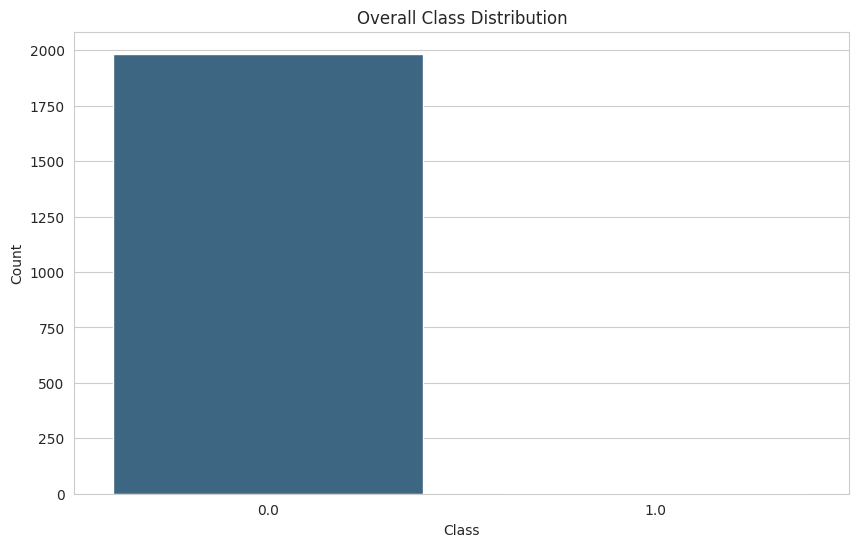

In [ ]:
plt.figure()
order = df['Class'].value_counts().index
sns.countplot(data=df, x='Class', hue='Class', order=order, palette='viridis', legend=False)
plt.title('Overall Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
# Display fraudulent transactions
fraud = df[df['Class'] == 1]

print("Total Fraud Transactions:", len(fraud))
display(fraud.head(20))

Total Fraud Transactions: 2


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,3.202033,-2.899907,-0.595222,-4.289254,0.389724,-1.140747,-2.830056,-0.016822,0.416956,0.126911,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.0,1.0
623,472,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,-0.414575,-0.503141,0.676502,-1.692029,2.000635,0.666780,0.599717,1.725321,0.283345,2.102339,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.0,1.0


In [ ]:
normal = df[df['Class'] == 0]

print("Total Normal Transactions:", len(normal))
normal.head()

Total Normal Transactions: 1984


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df['Class'].value_counts()

,count
Class,
0.0,1984
1.0,2


/tmp/ipykernel_1570/2683106140.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='Amount', order=order, showfliers=False, palette='crest')


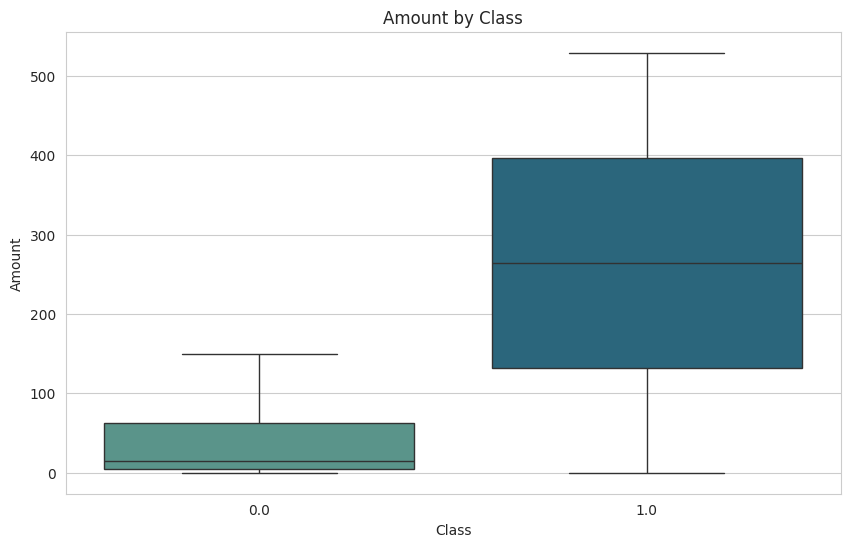

Class
1.0    264.50
0.0     15.09
Name: Amount, dtype: float64


In [ ]:
plt.figure()
sns.boxplot(data=df, x='Class', y='Amount', order=order, showfliers=False, palette='crest')
plt.title('Amount by Class')
plt.show()

print(df.groupby('Class')['Amount'].median().sort_values(ascending=False))


/tmp/ipykernel_1570/3763116365.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='Amount', order=order, ax=axes[0], palette='mako')
/tmp/ipykernel_1570/3763116365.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='V1', order=order, ax=axes[1], showfliers=False, palette='mako')


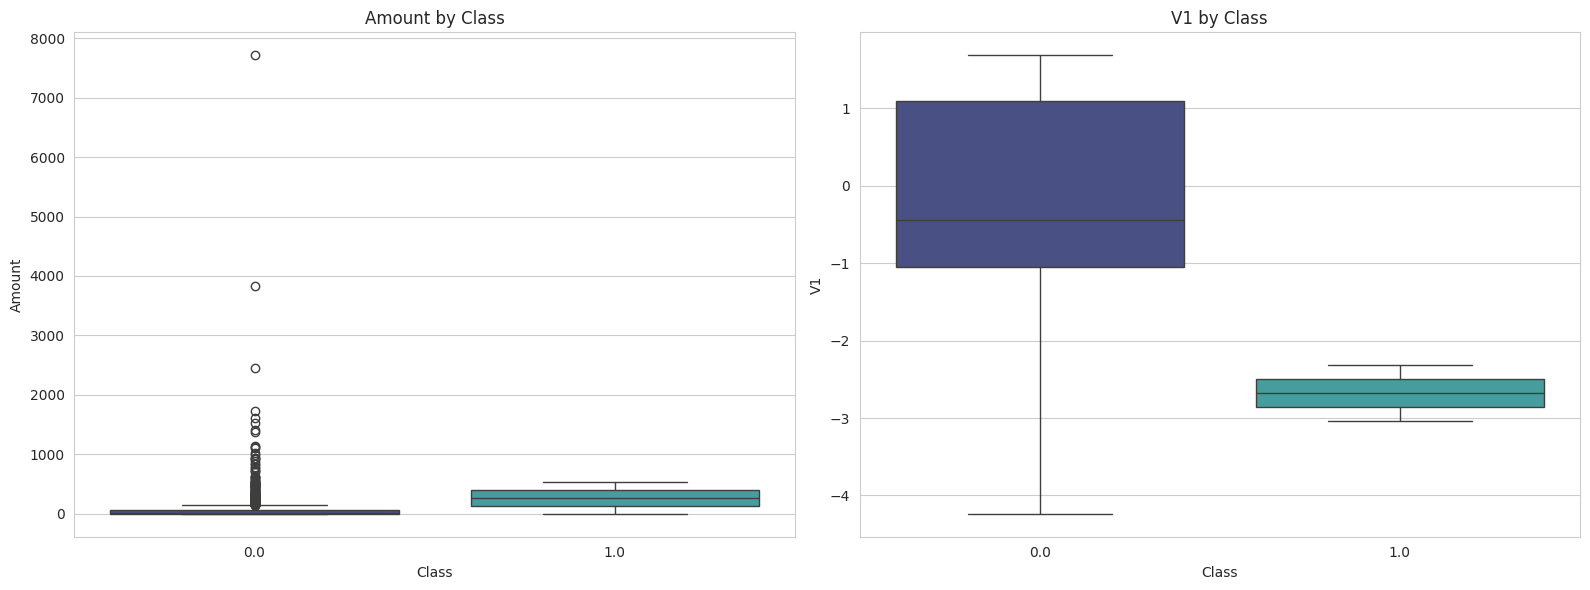

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Class', y='Amount', order=order, ax=axes[0], palette='mako')
axes[0].set_title('Amount by Class')

sns.boxplot(data=df, x='Class', y='V1', order=order, ax=axes[1], showfliers=False, palette='mako')
axes[1].set_title('V1 by Class')

plt.tight_layout()
plt.show()

In [ ]:
# Quantify with correlation against a numeric-encoded class for a rough signal
score_map = {s: i for i, s in enumerate(df['Class'].astype('category').cat.categories)}
df['_class_numeric'] = df['Class'].map(score_map)

corr_check = df[['_class_numeric', 'Amount', 'V1']].corr()['_class_numeric']
print(corr_check)

_class_numeric    1.000000
Amount            0.025752
V1               -0.056164
Name: _class_numeric, dtype: float64


/tmp/ipykernel_1570/3151620385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=low_amount_transactions, x='Class', y='V2', order=order, showfliers=False, palette='flare')


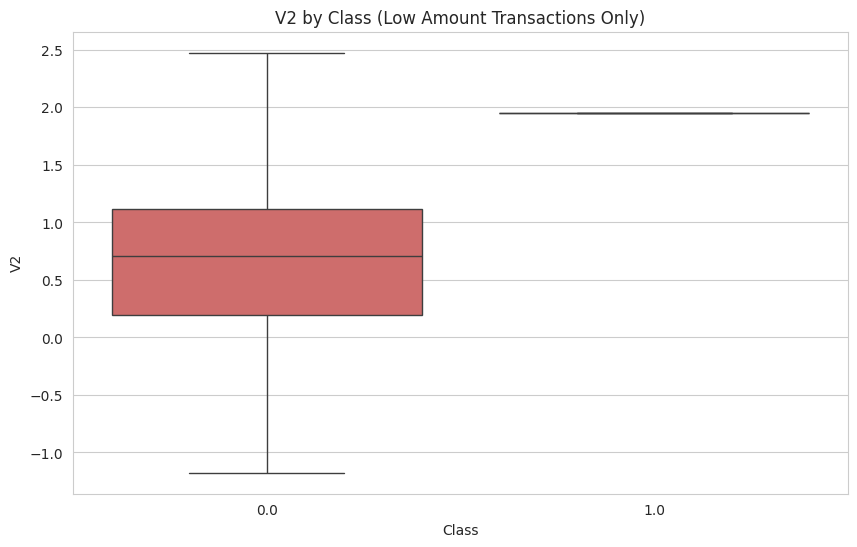

In [ ]:
# Define 'low amount transactions' as those below the median transaction amount
median_amount = df['Amount'].median()
low_amount_transactions = df[df['Amount'] <= median_amount]

plt.figure()
sns.boxplot(data=low_amount_transactions, x='Class', y='V2', order=order, showfliers=False, palette='flare')
plt.title('V2 by Class (Low Amount Transactions Only)')
plt.show()

/tmp/ipykernel_921/1818519914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='V2', order=order, showfliers=False, palette='rocket')


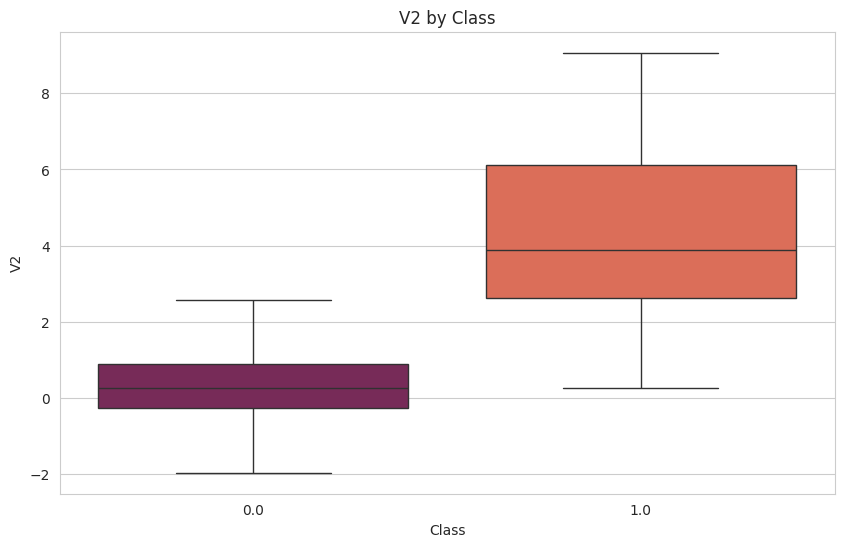

_class_numeric    1.000000
Amount            0.013117
V2                0.201003
Name: _class_numeric, dtype: float64


In [ ]:
plt.figure()
sns.boxplot(data=df, x='Class', y='V2', order=order, showfliers=False, palette='rocket')
plt.title('V2 by Class')
plt.show()

print(df[['_class_numeric', 'Amount', 'V2']].corr()['_class_numeric'])

/tmp/ipykernel_921/768233753.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='V3', order=order, palette='viridis')


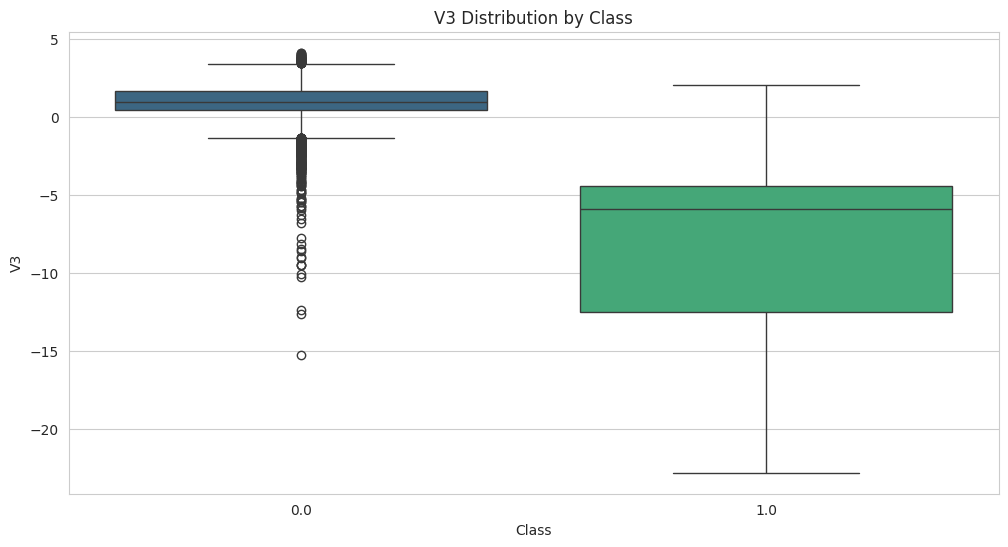

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Class', y='V3', order=order, palette='viridis')
plt.title('V3 Distribution by Class')
plt.show()

/tmp/ipykernel_921/3814929674.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='V4', order=order, palette='crest')


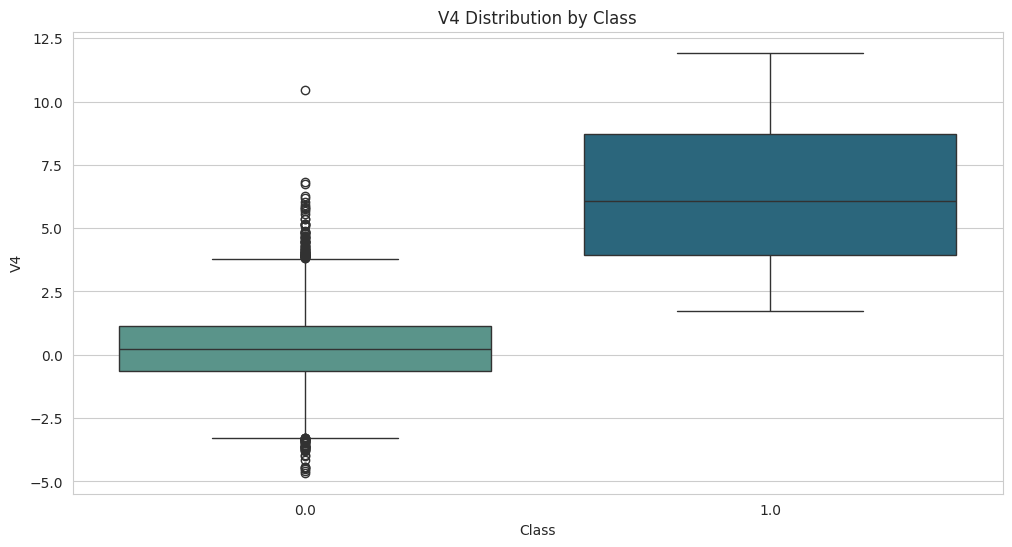

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Class', y='V4', order=order, palette='crest')
plt.title('V4 Distribution by Class')
plt.show()

In [ ]:
if 'Month' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='Month', hue='Credit_Score', hue_order=order, palette='mako')
    plt.title('Credit Score Trend by Month')
    plt.xticks(rotation=45)
    plt.show()


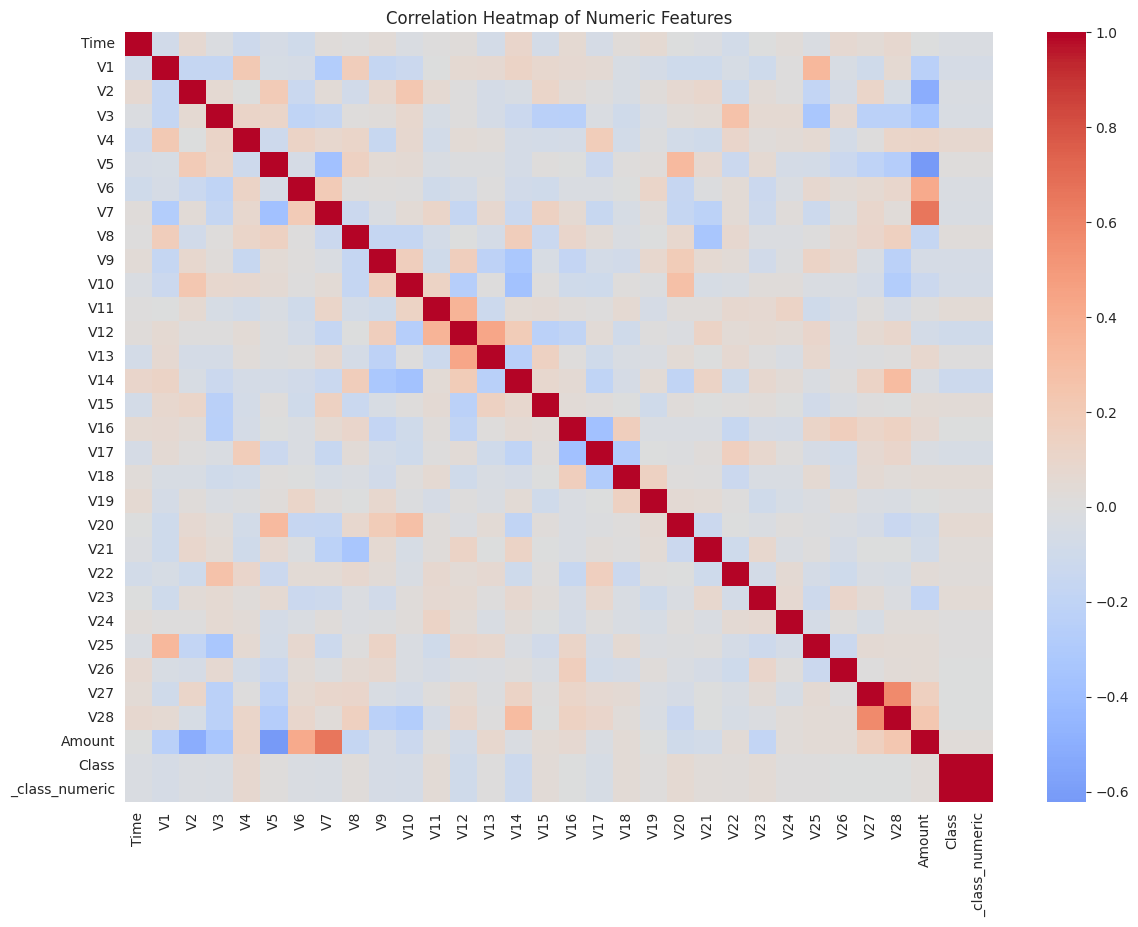

In [ ]:
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

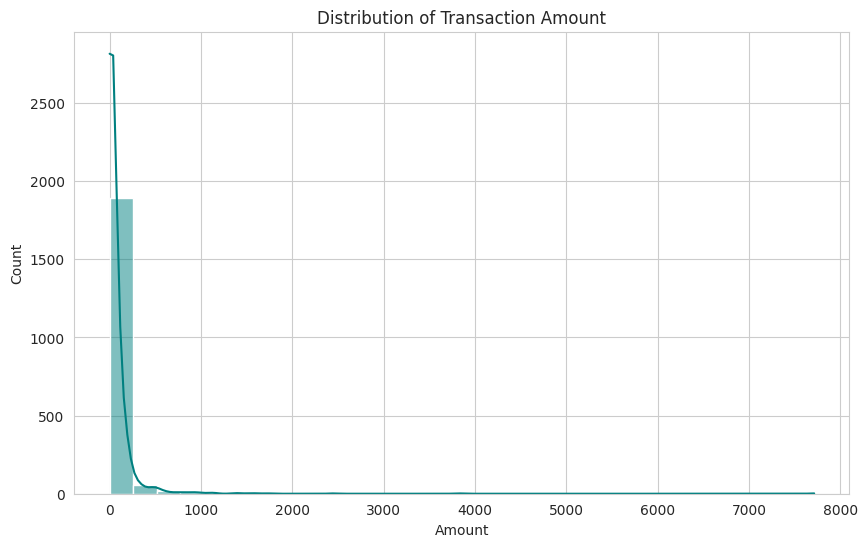

In [ ]:
plt.figure()
sns.histplot(df['Amount'], bins=30, kde=True, color='teal')
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.show()

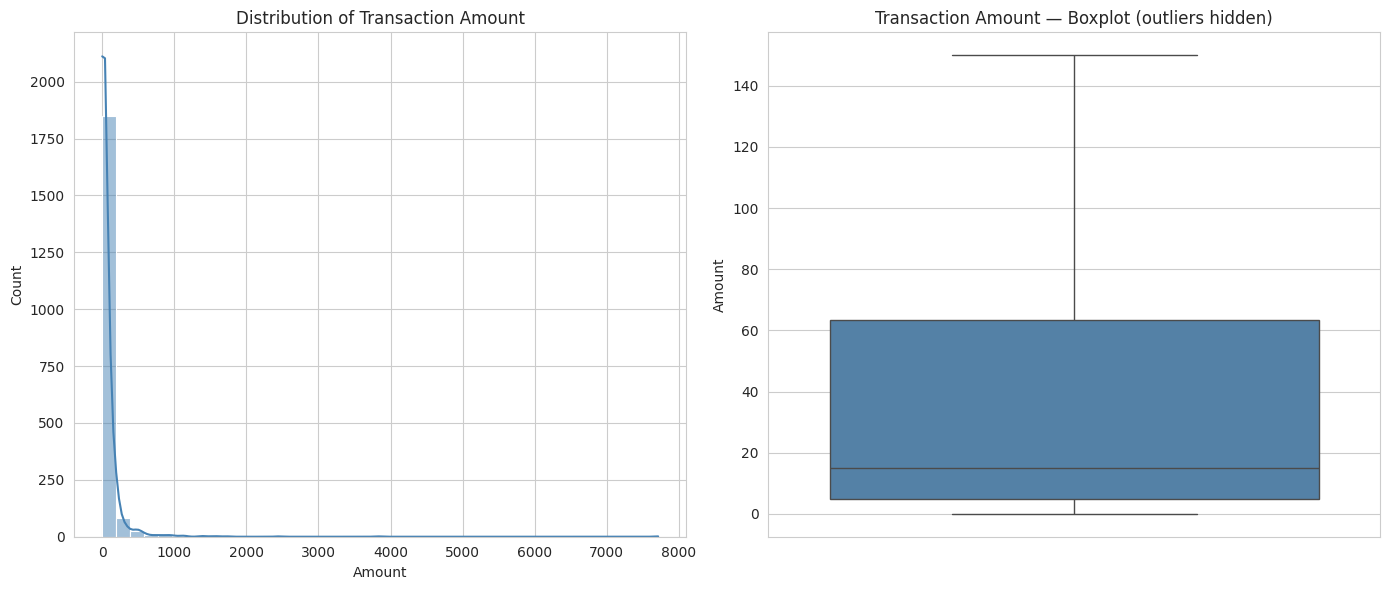

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['Amount'], bins=40, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Transaction Amount')
axes[0].set_xlabel('Amount')

sns.boxplot(y=df['Amount'], color='steelblue', ax=axes[1], showfliers=False)
axes[1].set_title('Transaction Amount — Boxplot (outliers hidden)')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.show()

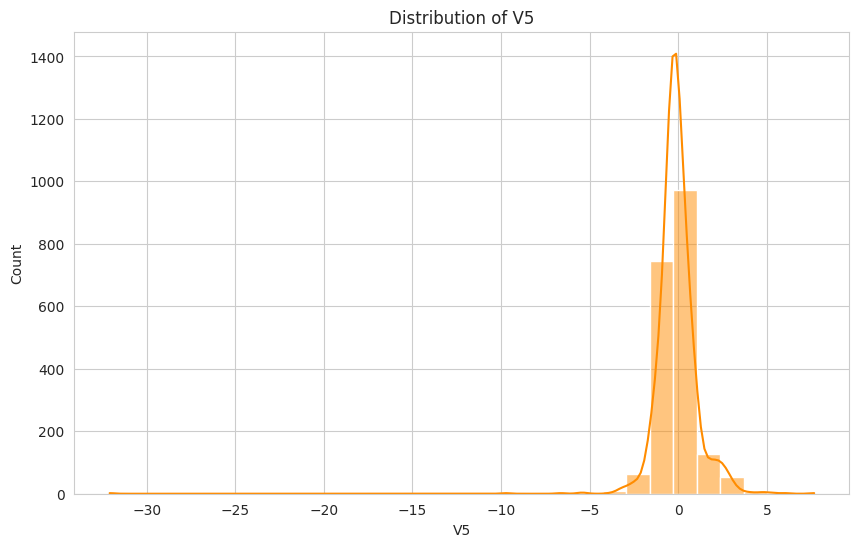

In [ ]:
plt.figure()
sns.histplot(df['V5'], bins=30, kde=True, color='darkorange')
plt.title('Distribution of V5')
plt.xlabel('V5')
plt.show()

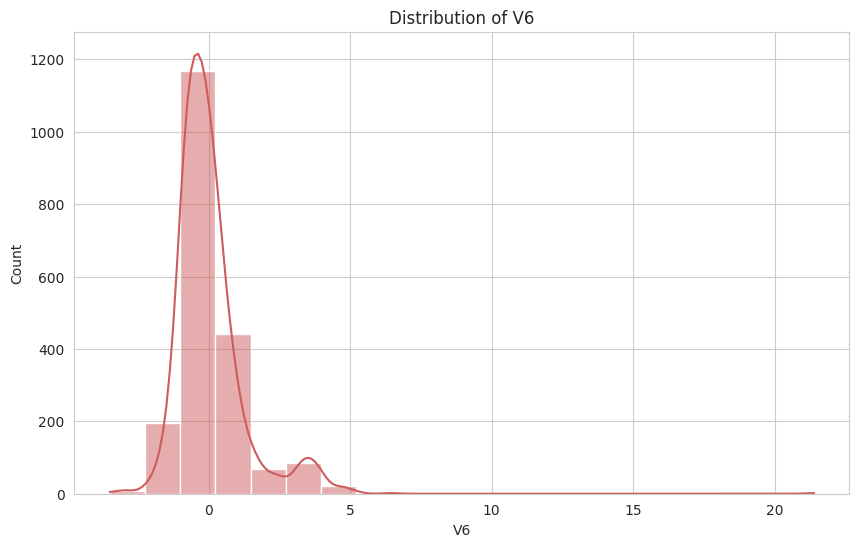

In [ ]:
plt.figure()
sns.histplot(df['V6'], bins=20, color='indianred', kde=True)
plt.title('Distribution of V6')
plt.xlabel('V6')
plt.show()

In [ ]:
if 'Occupation' in df.columns:
    plt.figure(figsize=(12, 6))
    df['Occupation'].value_counts().plot(kind='bar', color=sns.color_palette('mako', df['Occupation'].nunique()))
    plt.title('Customer Count by Occupation')
    plt.xlabel('Occupation')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1570/580242576.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='V7', order=order, showfliers=False, palette='crest')


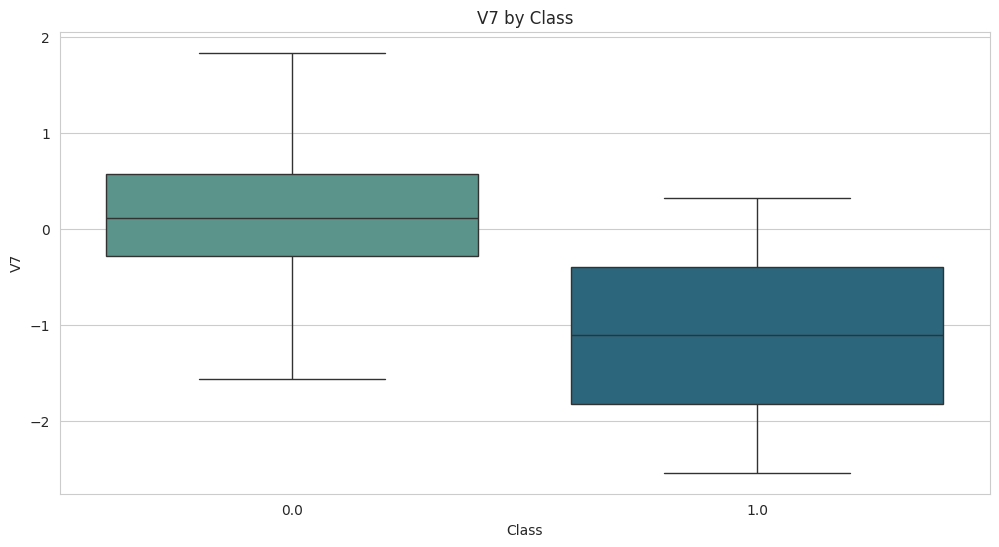

Class
0.0    0.117535
1.0   -1.105907
Name: V7, dtype: float64


In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Class', y='V7', order=order, showfliers=False, palette='crest')
plt.title('V7 by Class')
plt.xlabel('Class')
plt.ylabel('V7')
plt.show()

print(df.groupby('Class')['V7'].median().reindex(order))

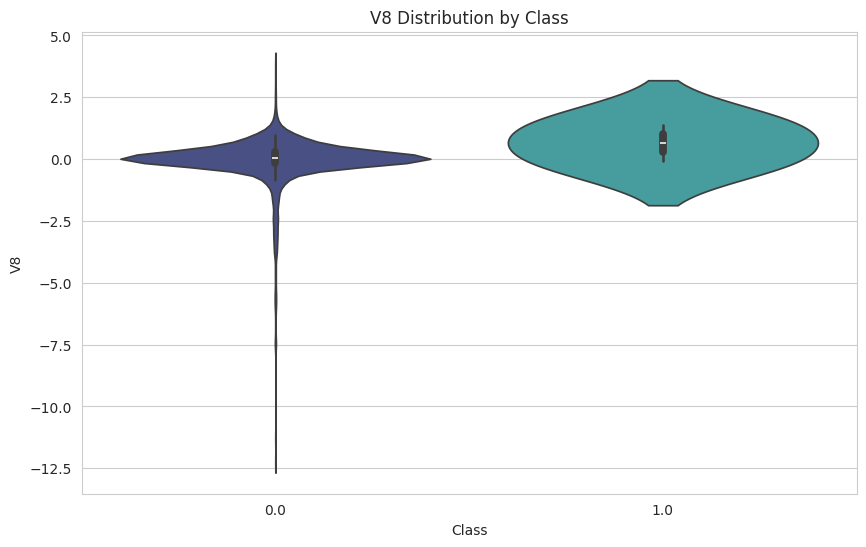

In [ ]:
plt.figure()
sns.violinplot(data=df, x='Class', y='V8', hue='Class', order=order, palette='mako', legend=False)
plt.title('V8 Distribution by Class')
plt.xlabel('Class')
plt.ylabel('V8')
plt.show()

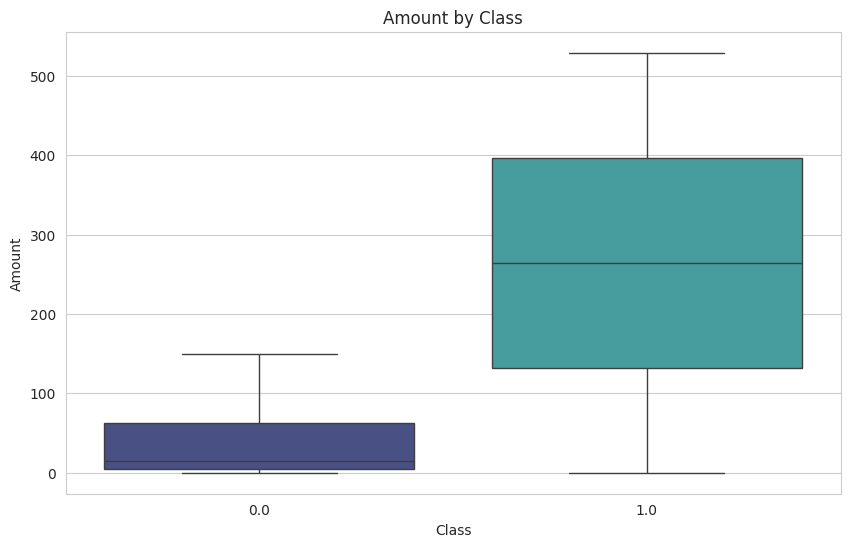

In [ ]:
plt.figure()
sns.boxplot(data=df, x='Class', y='Amount', order=order, showfliers=False, palette='mako', hue='Class', legend=False)
plt.title('Amount by Class')
plt.show()

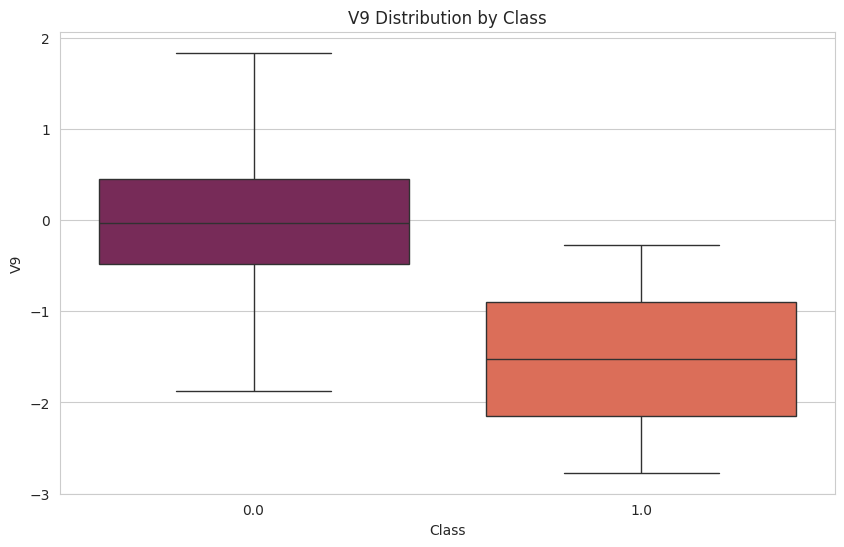

Correlation with Class (numeric-encoded):
_class_numeric    1.000000
V9               -0.054033
Name: _class_numeric, dtype: float64


In [ ]:
plt.figure()
sns.boxplot(data=df, x='Class', y='V9', order=order, showfliers=False, palette='rocket', hue='Class', legend=False)
plt.title('V9 Distribution by Class')
plt.show()

print('Correlation with Class (numeric-encoded):')
print(df[['_class_numeric', 'V9']].corr()['_class_numeric'])

In [ ]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', '_class_numeric'],
      dtype='object')


In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Age_Group', hue='Credit_Score', hue_order=order, palette='viridis')
plt.title('Credit Score Distribution by Age Group')
plt.show()

ValueError: Could not interpret value `Age_Group` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

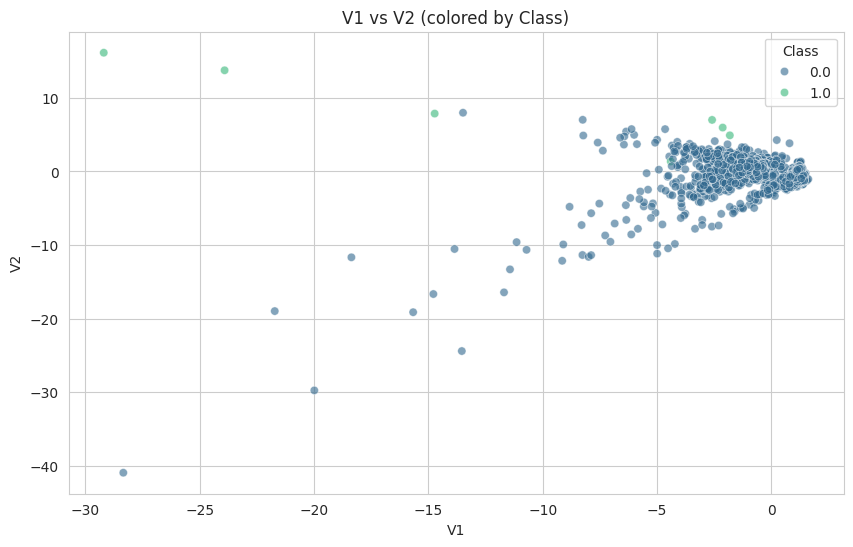

In [ ]:
plt.figure()
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=42),
                 x='V1', y='V2', hue='Class', hue_order=order,
                 palette='viridis', alpha=0.6)
plt.title('V1 vs V2 (colored by Class)')
plt.show()

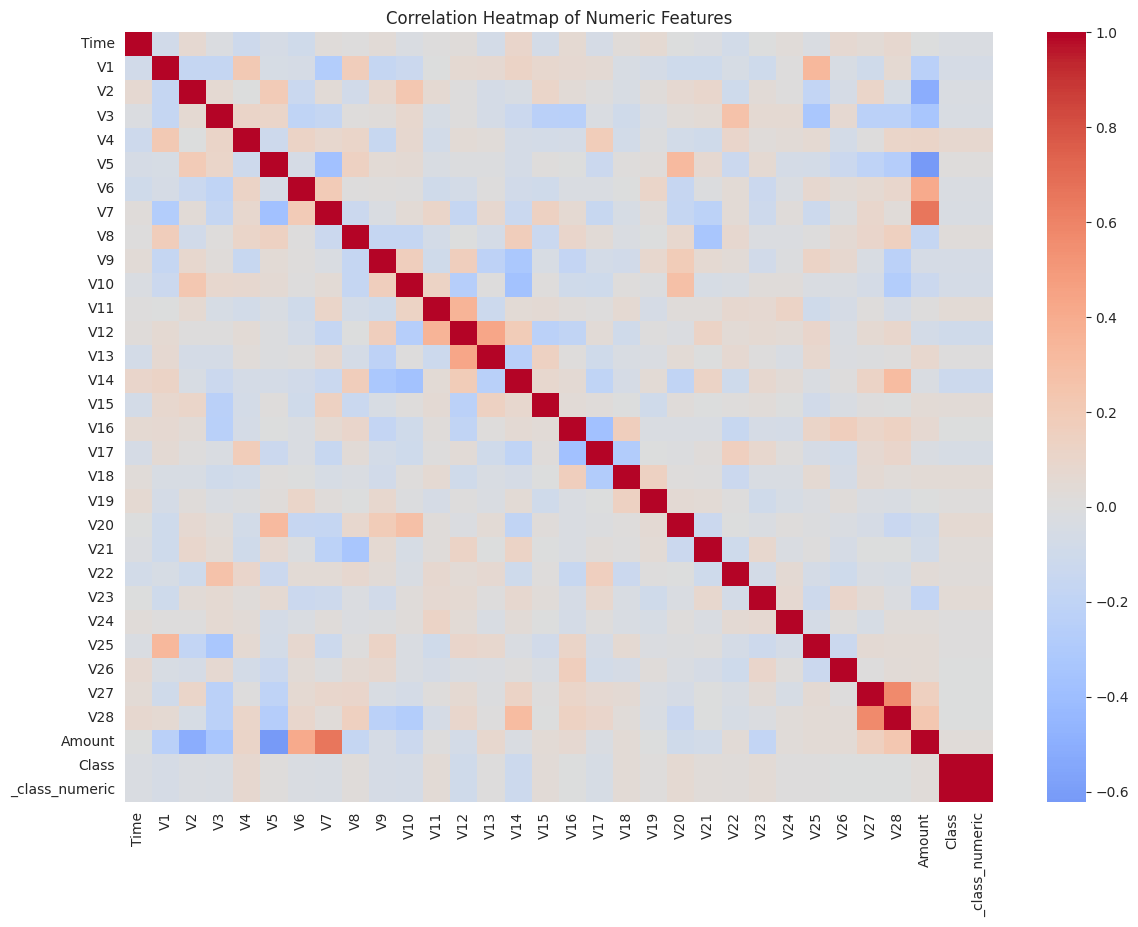

In [ ]:
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

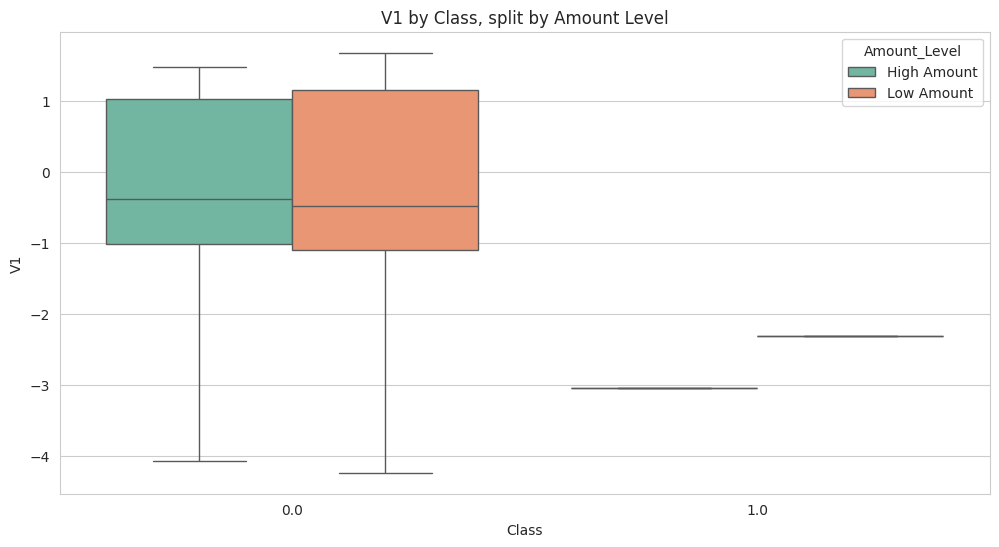

In [ ]:
# Split transactions into low vs high amount
median_amount_val = df['Amount'].median()
df['Amount_Level'] = np.where(df['Amount'] <= median_amount_val, 'Low Amount', 'High Amount')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Class', y='V1', hue='Amount_Level',
            order=order, showfliers=False, palette='Set2')
plt.title('V1 by Class, split by Amount Level')
plt.show()

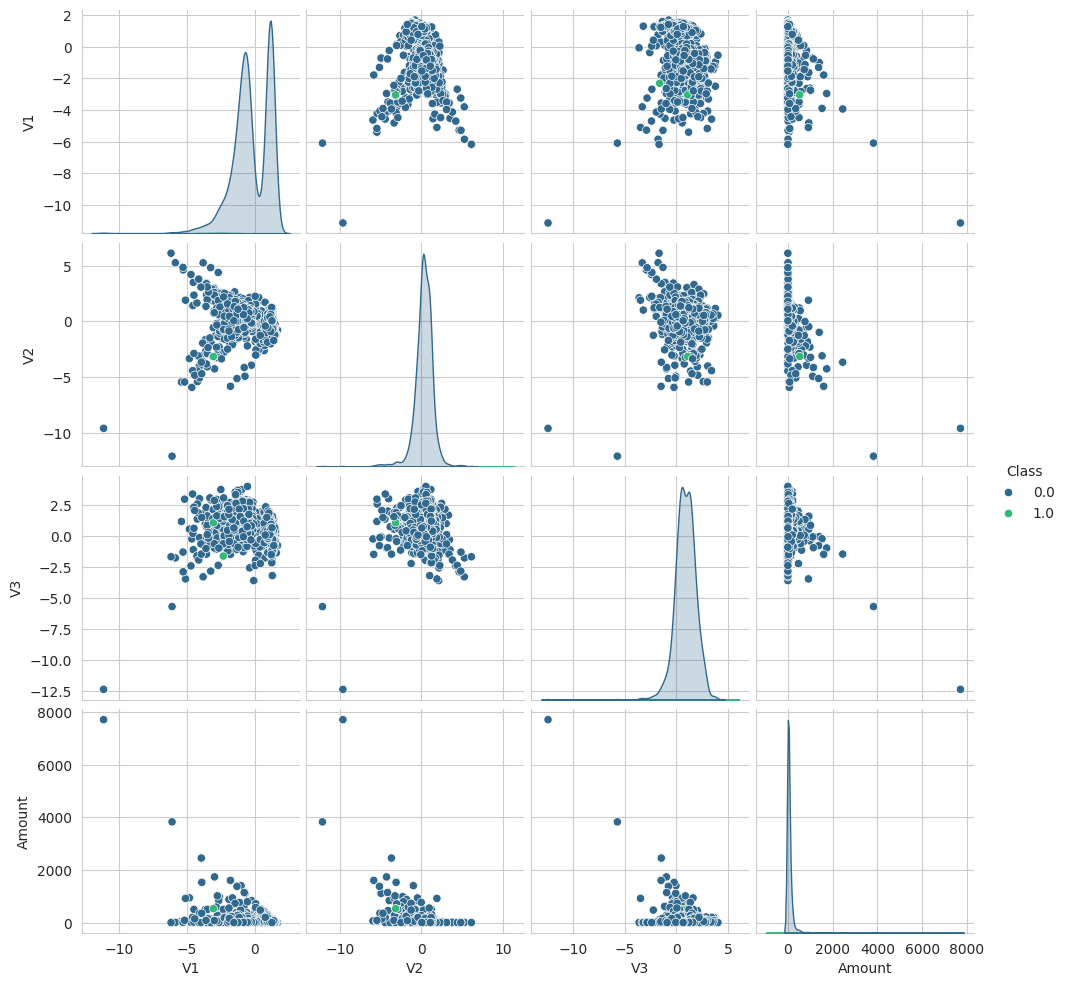

In [ ]:
pair_cols_present = ['V1', 'V2', 'V3', 'Amount', 'Class']

sns.pairplot(df[pair_cols_present].sample(min(2000, len(df)), random_state=42),
             hue='Class', hue_order=order, palette='viridis', diag_kind='kde')
plt.show()

In [ ]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', '_class_numeric', 'Amount_Level']


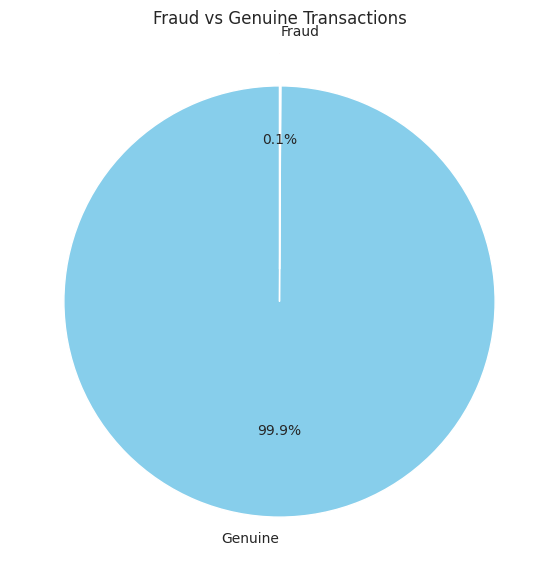

In [ ]:
plt.figure(figsize=(7,7))

labels = ['Genuine', 'Fraud']

plt.pie(
    df['Class'].value_counts(),
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'red'],
    explode=(0, 0.15)
)

plt.title("Fraud vs Genuine Transactions")
plt.show()

/tmp/ipykernel_1570/4043798930.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette=['skyblue', 'red'])


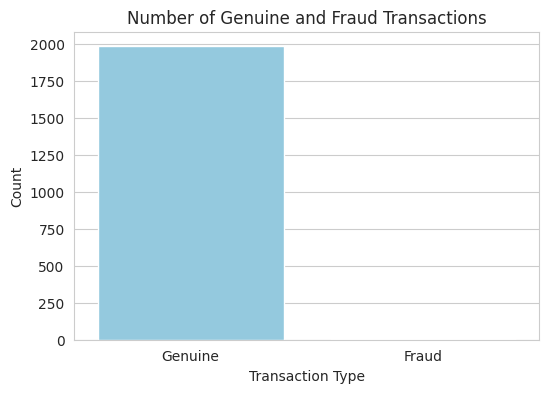

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Class', palette=['skyblue', 'red'])

plt.xticks([0,1], ['Genuine', 'Fraud'])
plt.title("Number of Genuine and Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

In [ ]:
class_counts = df['Class'].value_counts()
class_percent = (df['Class'].value_counts(normalize=True) * 100).round(2)

summary = class_counts.to_frame(name='Count')
summary['Percentage (%)'] = class_percent.values
summary.index = ['Genuine', 'Fraud']

summary

,Count,Percentage (%)
Genuine,1984,99.9
Fraud,2,0.1


/tmp/ipykernel_921/2730939091.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Genuine','Fraud'])


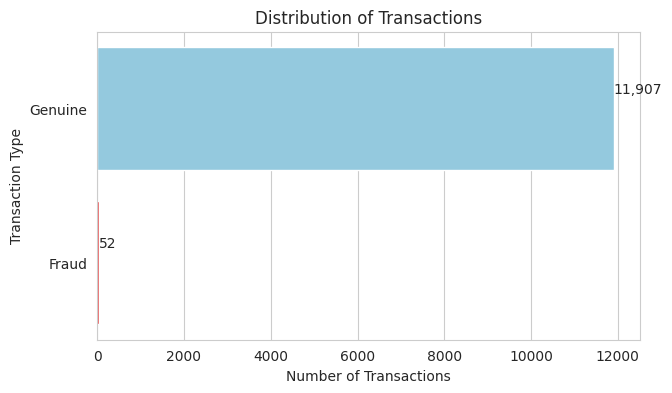

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=df,
    y='Class',
    hue='Class',
    palette=['skyblue','red'],
    legend=False
)

ax.set_yticklabels(['Genuine','Fraud'])

plt.title("Distribution of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Transaction Type")

for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}',
                (p.get_width(), p.get_y()+0.3),
                fontsize=10)

plt.show()

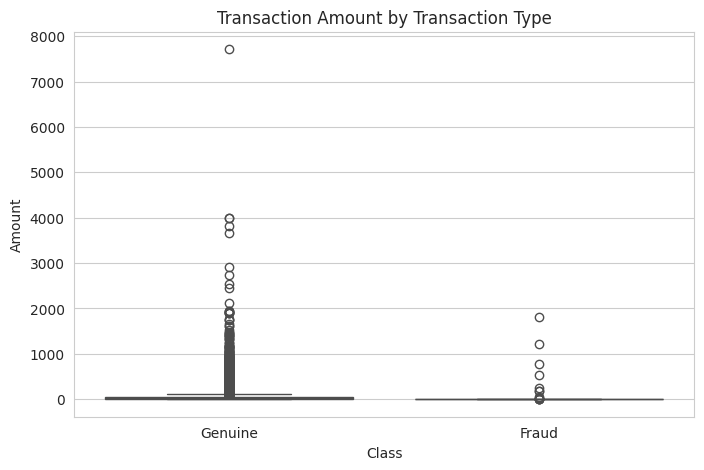

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Class',
    y='Amount',
    hue='Class',
    palette=['skyblue','red'],
    legend=False
)

plt.xticks([0,1],['Genuine','Fraud'])
plt.title("Transaction Amount by Transaction Type")

plt.show()

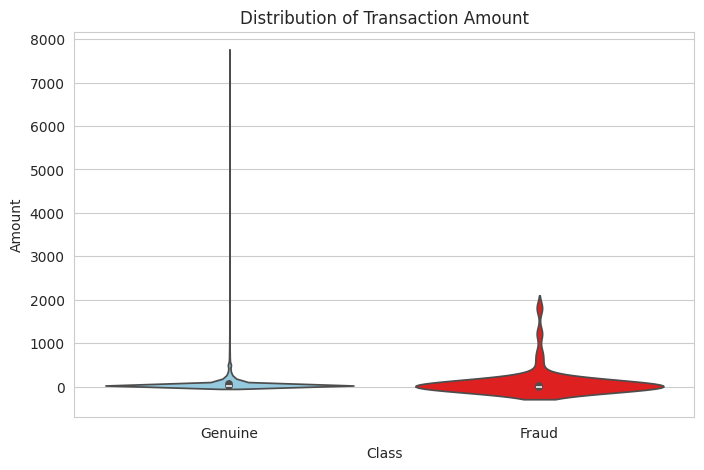

In [ ]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='Class',
    y='Amount',
    hue='Class',
    palette=['skyblue','red'],
    legend=False
)

plt.xticks([0,1],['Genuine','Fraud'])
plt.title("Distribution of Transaction Amount")

plt.show()

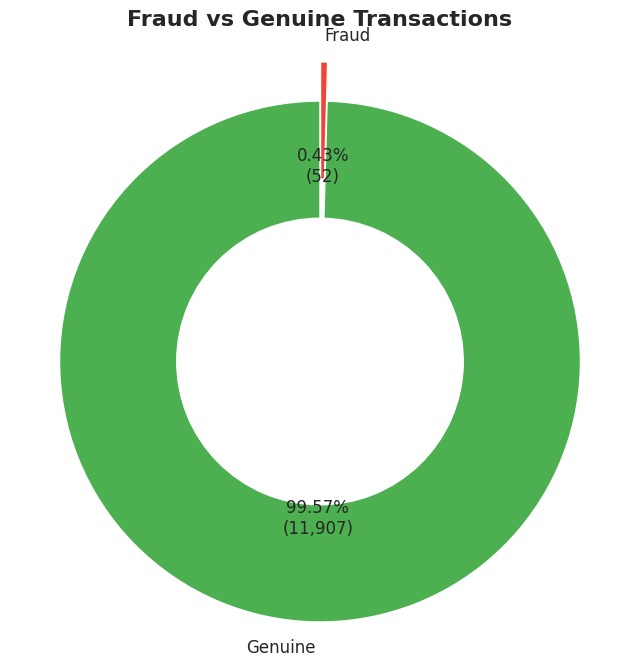

In [ ]:
import matplotlib.pyplot as plt

# Count transactions
counts = df['Class'].value_counts()

# Labels
labels = ['Genuine', 'Fraud']
colors = ['#4CAF50', '#F44336']   # Green = Genuine, Red = Fraud
explode = (0, 0.15)               # Highlight Fraud

plt.figure(figsize=(8,8))

plt.pie(
    counts,
    labels=labels,
    autopct=lambda p: f'{p:.2f}%\n({int(round(p*sum(counts)/100)):,})',
    startangle=90,
    colors=colors,
    explode=explode,
    wedgeprops=dict(width=0.45, edgecolor='white'),
    textprops={'fontsize':12}
)

plt.title("Fraud vs Genuine Transactions", fontsize=16, fontweight='bold')
plt.axis('equal')

plt.show()